# GRIB Data Inspection

Based on the meeting on Jun. 11 (https://github.com/SalishSeaCast/analysis-junqi/blob/main/Documentation_Meeting/Jun.11.md), this notebook inspects the 1-km resolution forcing fields from `results/forcing/atmospheric/GEM1.0/GRIB`. Those are `GRIB` files from 2020-Feb-07 to today.

## Test Reading

In [3]:
# Example reading

import xarray as xr

Example_path='/results/forcing/atmospheric/GEM1.0/GRIB/20200207/12/001/CMC_hrdps_west_VGRD_TGL_10_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2'

ds_example=xr.open_dataset(Example_path,engine='cfgrib')

In [4]:
# Print example

print(ds_example)

<xarray.Dataset> Size: 31MB
Dimensions:            (y: 1180, x: 1330)
Coordinates:
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 13MB ...
    longitude          (y, x) float64 13MB ...
    valid_time         datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    v10                (y, x) float32 6MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-06-17T18:22 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
print(ds_example['v10'].attrs['units'])

m s**-1


### File name list

1. `20200207/12/001/CMC_hrdps_west_APCP_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

2. `20200207/12/001/CMC_hrdps_west_APCP_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2.5b7b6.idx`

3. `20200207/12/001/CMC_hrdps_west_DLWRF_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

4. `20200207/12/001/CMC_hrdps_west_DSWRF_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

5. `20200207/12/001/CMC_hrdps_west_LHTFL_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

6. `20200207/12/001/CMC_hrdps_west_PRATE_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

7. `20200207/12/001/CMC_hrdps_west_PRMSL_MSL_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

8. `20200207/12/001/CMC_hrdps_west_SPFH_TGL_2_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

9. `20200207/12/001/CMC_hrdps_west_TCDC_SFC_0_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

10. `20200207/12/001/CMC_hrdps_west_TMP_TGL_2_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

11. `20200207/12/001/CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`

12. `20200207/12/001/CMC_hrdps_west_VGRD_TGL_10_rotated_latlon0.009x0.009_20200207T12Z_P001-00.grib2`



### Variables

| File Name | Variable | 变量 | 所在高度  |
| :--- | :--- | :--- | :--- |
| **APCP** | Accumulated Precipitation | **累积降水量** | `SFC_0` (地表) |
| **DLWRF** | Downward Long-Wave Radiation Flux | **向下长波辐射通量** | `SFC_0` (地表) |
| **DSWRF** | Downward Short-Wave Radiation Flux | **向下短波辐射通量** | `SFC_0` (地表) |
| **LHTFL** | Latent Heat Net Flux | **潜热通量** | `SFC_0` (地表) |
| **PRATE** | Precipitation Rate | **降水率** | `SFC_0` (地表) |
| **PRMSL** | Pressure reduced to Mean Sea Level | **海平面气压** | `MSL_0` (平均海平面) |
| **SPFH** | Specific Humidity | **比湿** | `TGL_2` (距地2米) |
| **TCDC** | Total Cloud Cover | **总云量** | `SFC_0` (地表) |
| **TMP** | Temperature | **温度** | `TGL_2` (距地2米) |
| **UGRD** | U-Component of Wind | **U风分量** (纬向风/东西向) | `TGL_10` (距地10米) |
| **VGRD** | V-Component of Wind | **V风分量** (经向风/南北向) | `TGL_10` (距地10米) |



We need `UGRD` and `VGRD` to calculate maximum wind speed, possibly at `Sandheads` (49.11, -123.3). I believe that HRDPS simulates the future 36 hours every 12 hours. Just for convenience, we extract wind speed from `/00` for the wind speed in the whole day, from `yyyymmdd/00/001` to `yyyymmdd/00/024`. 

## Data Extraction

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
from concurrent.futures import ProcessPoolExecutor, as_completed
MAX_WORKERS = 8

# ================= 配置参数 =================
BASE_DIR = '/results/forcing/atmospheric/GEM1.0/GRIB'
START_DATE = datetime(2020, 2, 8)
END_DATE = datetime(2026, 5, 1) 
TARGET_LAT = 49.11
TARGET_LON = -123.3 
OUTPUT_CSV = 'Data_HRDPS_Sandheads.csv'
# ============================================

# ============================================

def find_nearest_grid_indices(lat_array, lon_array, target_lat, target_lon):
    """计算距离目标经纬度最近的网格点索引 (y, x)"""
    dist_sq = (lat_array - target_lat)**2 + (lon_array - target_lon)**2
    y_idx, x_idx = np.unravel_index(np.argmin(dist_sq, axis=None), dist_sq.shape)
    return y_idx, x_idx

def get_target_indices_from_first_file():
    """初始化网格坐标"""
    current_date = START_DATE
    while current_date <= END_DATE:
        date_str = current_date.strftime('%Y%m%d')
        time_stamp = f"{date_str}T00Z"
        u_filename = f"CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P001-00.grib2"
        u_path = os.path.join(BASE_DIR, date_str, '00', '001', u_filename)
        
        if os.path.exists(u_path):
            print(f"[*] 正在通过 {u_path} 初始化网格坐标...")
            ds_u = xr.open_dataset(u_path, engine='cfgrib')
            lat_array = ds_u['latitude'].values
            lon_array = ds_u['longitude'].values
            y_idx, x_idx = find_nearest_grid_indices(lat_array, lon_array, TARGET_LAT, TARGET_LON)
            
            actual_lat = lat_array[y_idx, x_idx]
            actual_lon = lon_array[y_idx, x_idx]
            print(f"[+] 初始化完成！网格索引: (y={y_idx}, x={x_idx}), 实际坐标: ({actual_lat:.4f}, {actual_lon:.4f})")
            ds_u.close()
            return y_idx, x_idx
        current_date += timedelta(days=1)
    raise FileNotFoundError("没有找到任何有效 GRIB 文件！")

def process_single_day(date_obj, target_y, target_x):
    """处理单天数据"""
    daily_results = []
    date_str = date_obj.strftime('%Y%m%d')
    time_stamp = f"{date_str}T00Z"
    
    for hour in range(1, 25):
        hour_str = f"{hour:03d}"
        u_filename = f"CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P{hour_str}-00.grib2"
        v_filename = f"CMC_hrdps_west_VGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P{hour_str}-00.grib2"
        
        u_path = os.path.join(BASE_DIR, date_str, '00', hour_str, u_filename)
        v_path = os.path.join(BASE_DIR, date_str, '00', hour_str, v_filename)
        
        if not os.path.exists(u_path) or not os.path.exists(v_path):
            continue
            
        try:
            ds_u = xr.open_dataset(u_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
            ds_v = xr.open_dataset(v_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
            
            u_var_name = list(ds_u.data_vars)[0]
            v_var_name = list(ds_v.data_vars)[0]

            u_val = float(ds_u[u_var_name].isel(y=target_y, x=target_x).values)
            v_val = float(ds_v[v_var_name].isel(y=target_y, x=target_x).values)
            
            wind_speed = np.sqrt(u_val**2 + v_val**2)
            valid_time = ds_u['valid_time'].values
            
            daily_results.append({
                'run_date': date_obj.strftime('%Y-%m-%d'),
                'forecast_hour': hour,
                'valid_time': valid_time,
                'U_component': u_val,
                'V_component': v_val,
                'wind_speed': wind_speed
            })
            ds_u.close()
            ds_v.close()
        except Exception:
            pass
            
    return daily_results

def main():
    # 1. 初始化索引
    try:
        target_y, target_x = get_target_indices_from_first_file()
    except Exception as e:
        print(f"[-] 初始化失败: {e}")
        return

    # 2. 检查是否有已经跑完的数据（支持断点续传）
    processed_dates = set()
    file_exists = os.path.exists(OUTPUT_CSV)
    
    if file_exists:
        try:
            existing_df = pd.read_csv(OUTPUT_CSV)
            if not existing_df.empty and 'run_date' in existing_df.columns:
                processed_dates = set(existing_df['run_date'].unique())
                print(f"[*] 检测到已存在的CSV文件，已跳过 {len(processed_dates)} 天的数据。")
        except Exception:
            # 如果文件损坏或为空，则重新创建
            file_exists = False

    # 如果文件不存在，先初始化表头
    if not file_exists:
        header_df = pd.DataFrame(columns=['run_date', 'forecast_hour', 'valid_time', 'U_component', 'V_component', 'wind_speed'])
        header_df.to_csv(OUTPUT_CSV, index=False)

    # 3. 生成需要处理的日期列表（剔除已处理的）
    dates_to_process = []
    current = START_DATE
    while current <= END_DATE:
        if current.strftime('%Y-%m-%d') not in processed_dates:
            dates_to_process.append(current)
        current += timedelta(days=1)

    total_days = len(dates_to_process)
    if total_days == 0:
        print("[+] 所有日期均已处理完成，无需重复运行！")
        return
        
    print(f"[*] 剩余 {total_days} 天的数据需要处理。启动 {MAX_WORKERS} 个并行进程...")

    # 4. 进程池跑起来
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_date = {
            executor.submit(process_single_day, date, target_y, target_x): date 
            for date in dates_to_process
        }
        
        completed_count = 0
        for future in as_completed(future_to_date):
            date_obj = future_to_date[future]
            completed_count += 1
            
            try:
                daily_data = future.result()
                if daily_data:
                    # 【核心改进】一旦拿到一天的数据，立刻追加写入CSV，绝不压榨内存
                    df_day = pd.DataFrame(daily_data)
                    df_day.to_csv(OUTPUT_CSV, mode='a', header=False, index=False)
                
                # 每50天提示一次
                if completed_count % 50 == 0:
                    print(f"[进度提示] 已成功写入: {date_obj.strftime('%Y-%m-%d')} | 当期进度: {completed_count}/{total_days} 天")
                    
            except Exception as exc:
                print(f"[-] 日期 {date_obj.strftime('%Y-%m-%d')} 处理失败: {exc}")

    print(f"[+] 恭喜！所有数据提取完毕，已安全保存至 {OUTPUT_CSV}")

if __name__ == "__main__":
    main()

## Sandheads Time Series (HRDPS 1km)

In [8]:
import pandas as pd

path_sh='Data_HRDPS_Sandheads.csv'

df=pd.read_csv(path_sh)

print(df.head())

     run_date  forecast_hour           valid_time  U_component  V_component  \
0  2020-02-08              1  2020-02-08 01:00:00     4.122551     8.263034   
1  2020-02-08              2  2020-02-08 02:00:00     6.499862     5.755482   
2  2020-02-08              3  2020-02-08 03:00:00     4.200695     5.254703   
3  2020-02-08              4  2020-02-08 04:00:00     1.629470     6.365723   
4  2020-02-08              5  2020-02-08 05:00:00     1.463473     9.173620   

   wind_speed  
0    9.234347  
1    8.681808  
2    6.727387  
3    6.570966  
4    9.289621  


### Maximum wind speed

最大风速为: 18.89, 发生时间: 2024-12-14 17:00:00


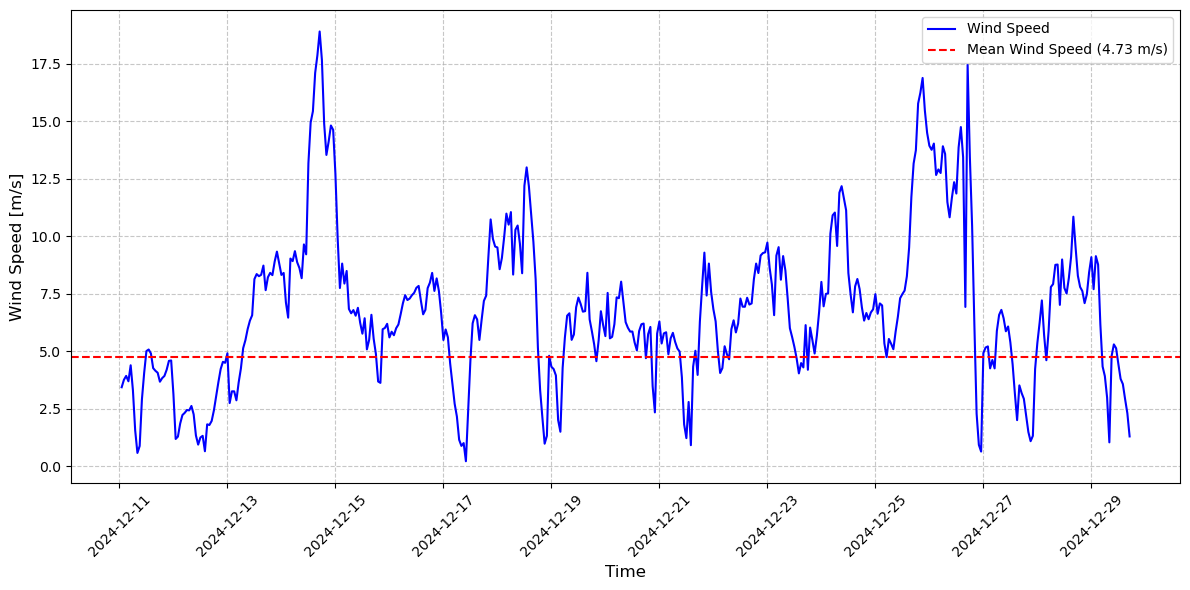

In [ ]:
# Wind speed maximum

import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Calculate mean windspeed

mean_wind_speed=df['wind_speed'].mean()

#  将 'valid_time' 列转换为 datetime 格式，以便进行时间序列操作
df['valid_time'] = pd.to_datetime(df['valid_time'])

df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 找到绝对风速的最大值及其所在的行
max_idx = df['wind_speed'].idxmax()
max_wind_speed = df.loc[max_idx, 'wind_speed']
max_wind_time = df.loc[max_idx, 'valid_time']

print(f"最大风速为: {max_wind_speed:.2f}, 发生时间: {max_wind_time}")

# 确定时间窗口：最大风速时间点的前后各 15 天（总共约 1 个月）
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
df_month = df.loc[mask]

# 绘制折线图
plt.figure(figsize=(12, 6))

# 画出风速折线
plt.plot(df_month['valid_time'], df_month['wind_speed'], label='Wind Speed', color='b')

# Wind speed mean
plt.axhline(y=mean_wind_speed, color='r', linestyle='--', label=f'Mean Wind Speed ({mean_wind_speed:.2f} m/s)')

# 图表美化与设置

plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # x轴时间倾斜45度，防止重叠
plt.legend()
plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域

# 显示图像
plt.show()

In [18]:
print(max_wind_time)

2024-12-14 17:00:00


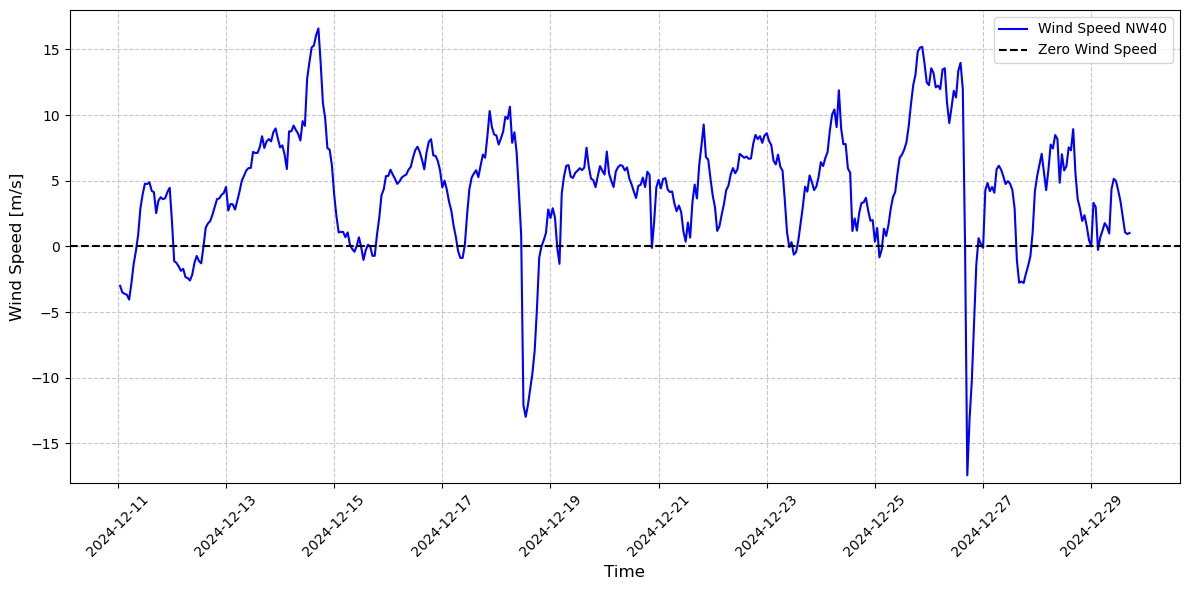

In [ ]:
# Wind along the strait (during that time)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

#  将 'valid_time' 列转换为 datetime 格式，以便进行时间序列操作
df['valid_time'] = pd.to_datetime(df['valid_time'])

df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# Positive direction: NW45

wind_speed_NW40 = -df['U_component'] * np.cos(np.radians(45)) + df['V_component'] * np.cos(np.radians(45))

# 确定时间窗口：最大风速时间点的前后各 15 天（总共约 1 个月）

max_wind_time = pd.to_datetime('2024-12-14 17:00:00')
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_NW40_month = wind_speed_NW40.loc[mask]
df_month = df.loc[mask]

# 绘制折线图
plt.figure(figsize=(12, 6))

# 画出风速折线
plt.plot(df_month['valid_time'], wind_speed_NW40_month, label='Wind Speed NW40', color='b')
plt.axhline(y=0, color='k', linestyle='--', label=f'Zero Wind Speed')

# 图表美化与设置

plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # x轴时间倾斜45度，防止重叠
plt.legend()
plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
plt.ylim([-18,18])

# 显示图像
plt.show()

### Maximum Wind Speed aloing the Strait (NW40)

【自动定位】沿海峡风速绝对值最大出现在: 2021-03-29 04:00:00
【对应风速】此时的投影风速为: -18.25 m/s


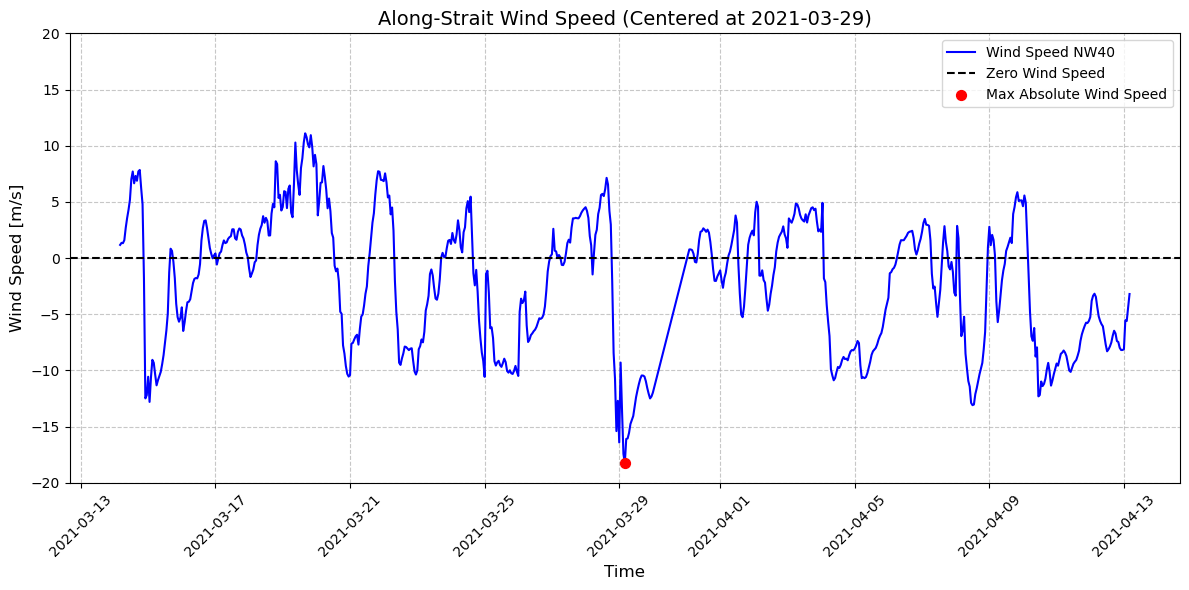

In [ ]:
# Time series around Maxmimum wind speed along NW40
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# 假设 df 已经读取
# df = pd.read_csv('Data_HRDPS_Sandheads.csv')

# 1. 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 2. 计算沿海峡方向（Positive direction: NW 40）的风速
# 注意：这里需要转换为弧度进行三角函数计算
wind_speed_NW40 = -df['U_component'] * np.cos(np.radians(50)) + df['V_component'] * np.cos(np.radians(40))


# 3. 找出沿海峡风速“绝对值”最大的一项所在的索引
max_abs_idx = wind_speed_NW40.abs().idxmax()

# 提取出真正的时间和此时的风速真实值（带正负号）
max_wind_time = df.loc[max_abs_idx, 'valid_time']
max_wind_val = wind_speed_NW40.loc[max_abs_idx]

print(f"【自动定位】沿海峡风速绝对值最大出现在: {max_wind_time}")
print(f"【对应风速】此时的投影风速为: {max_wind_val:.2f} m/s")
# ----------------------------------------------------

# 4. 确定时间窗口：最大风速时间点的前后各 15 天（总共约 1 个月）
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 5. 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_NW40_month = wind_speed_NW40.loc[mask]
df_month = df.loc[mask]

# 6. 绘制折线图
plt.figure(figsize=(12, 6))

# 画出沿海峡风速折线
plt.plot(df_month['valid_time'], wind_speed_NW40_month, label='Wind Speed NW40', color='b')

# 标出 0 线基准
plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')

# （可选）在图上把这个绝对值最大的点用红星标出来，一眼就能看到为什么选这段时间
plt.scatter([max_wind_time], [max_wind_val], color='red', marker='o', s=50, zorder=5, label='Max Absolute Wind Speed')

# 图表美化与设置

plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # x轴时间倾斜45度，防止重叠
plt.legend()
plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
plt.ylim([-20, 20]) # 锁定 Y 轴范围

# 显示图像
plt.show()

### Continuous high wind event (storm)



In [29]:
import pandas as pd


# df['valid_time'] = pd.to_datetime(df['valid_time'])
# df = df.sort_values(by='valid_time').reset_index(drop=True)

# --- 1. 设置大风事件的筛选标准 ---
wind_threshold = 10.0  # 大风阈值 (m/s)
duration_threshold = 24 # 最少持续时间 (行数，即小时数)

# 注意：这里用的是原始的风速(wind_speed)。
is_high_wind = wind_speed_NW40.abs() >= wind_threshold
# is_high_wind = df['wind_speed'] >= wind_threshold

# --- 2. 核心技巧：给连续的大风时段打上同一个标签 ---
# (~is_high_wind).cumsum() 的作用是：每遇到一个不满足条件的行，累加器就加1。
# 这样一来，夹在中间的连续满足条件的行，就会拥有完全相同的累加ID。
event_id = (~is_high_wind).cumsum()

# --- 3. 把满足条件的数据挑出来，并按事件 ID 分组 ---
high_wind_events = df[is_high_wind].groupby(event_id)

# --- 4. 统计并筛选每次持续事件的信息 ---
events_summary = []
for _, group in high_wind_events:
    duration = len(group) # 因为是一小时一条数据，所以组内的数据条数就是持续的小时数
    
    if duration >= duration_threshold:
        start_time = group['valid_time'].iloc[0]
        end_time = group['valid_time'].iloc[-1]
        max_speed = group['wind_speed'].max()
        
        events_summary.append({
            'Start Time': start_time,
            'End Time': end_time,
            'Duration (hours)': duration,
            'Max Wind Speed (m/s)': max_speed
        })

# --- 5. 整理打印结果 ---
if events_summary:
    # 转换成 DataFrame 方便查看
    df_events = pd.DataFrame(events_summary)
    
    # 按照持续时间从长到短排个序，把最夸张的事件放前面
    df_events = df_events.sort_values(by='Duration (hours)', ascending=False).reset_index(drop=True)
    
    print(f"一共找到了 {len(df_events)} 次持续大风事件！\n")
    # 打印前 20 个最长的事件瞧瞧
    print(df_events.head(20).to_string()) 
else:
    print("在这个标准下，没有找到持续的大风事件。你可以尝试调低阈值试试。")

一共找到了 4 次持续大风事件！

           Start Time            End Time  Duration (hours)  Max Wind Speed (m/s)
0 2023-06-05 03:00:00 2023-06-06 15:00:00                37             15.242588
1 2025-04-15 03:00:00 2025-04-16 12:00:00                34             13.996384
2 2022-09-07 11:00:00 2022-09-08 11:00:00                25             15.612172
3 2021-10-25 02:00:00 2021-10-26 01:00:00                24             17.145209


According to the results above, the most significant wind event happened during 2023-06-05 to 2023-06-06, with a duration of 37 hours, the maximum speed is over 15 m/s.

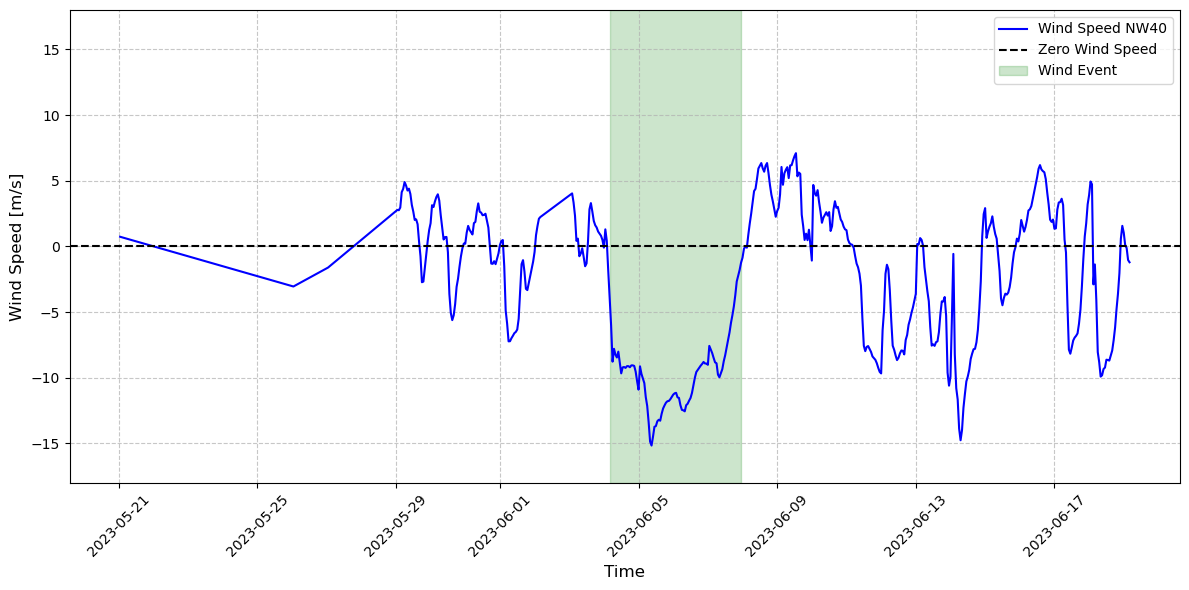

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta


df = pd.read_csv('Data_HRDPS_Sandheads.csv')

# 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 计算沿海峡方向风速 (Positive direction: NW 40)
wind_speed_NW40 = -df['U_component'] * np.cos(np.radians(45)) + df['V_component'] * np.cos(np.radians(45))


event_start = pd.to_datetime('2023-06-04 04:00:00') 
event_end = pd.to_datetime('2023-06-07 23:00:00')



# 确定绘图的时间窗口：这里我们直接用事件的开始时间作为中心，前后各看 15 天
max_wind_time = event_start 
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_NW40_month = wind_speed_NW40.loc[mask]
df_month = df.loc[mask]

# Visualization
plt.figure(figsize=(12, 6))

# 1. 画出风速折线和 0 基准线
plt.plot(df_month['valid_time'], wind_speed_NW40_month, label='Wind Speed NW40', color='b')
plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')


# background colour
plt.axvspan(event_start, event_end, color='green', alpha=0.2, label='Wind Event')

# 3. 图表美化与设置
plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) 

# 将图例放在外面或者最优位置，避免挡住高亮区域
plt.legend(loc='upper right') 
plt.tight_layout() 
plt.ylim([-18, 18])

# 显示图像
plt.show()

The continuous wind event happende during `2023-06-04 04:00:00` and `2023-06-07 23:00:00`. 

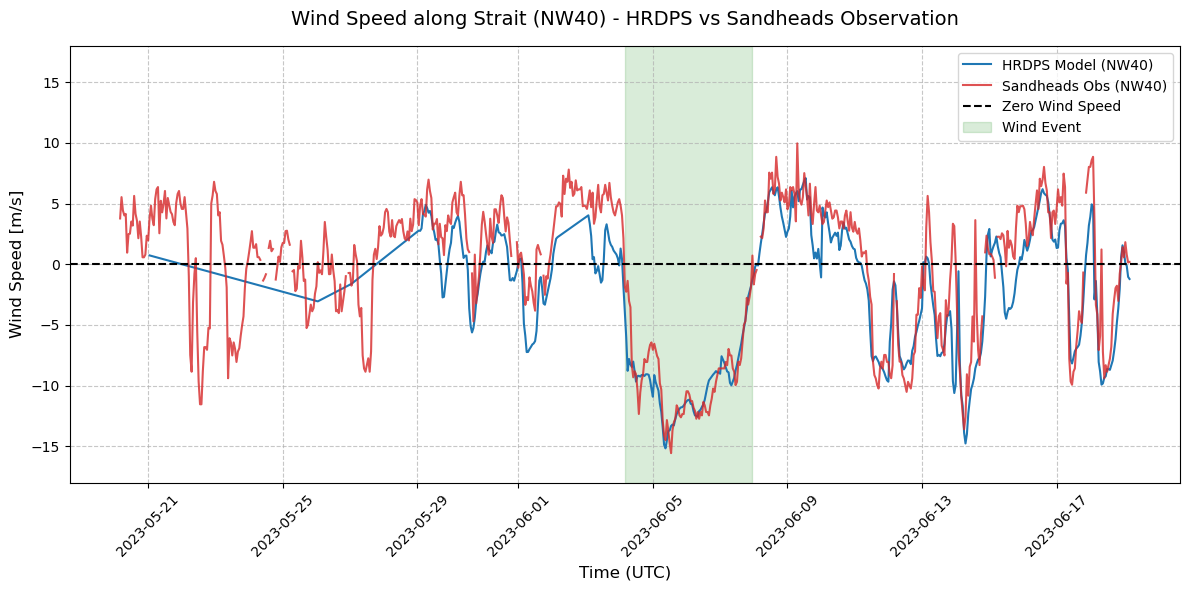

In [5]:
# 1km HRDPS + Observation

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# ==========================================
# 1. 读取并处理 HRDPS 模型数据
# ==========================================
df = pd.read_csv('Data_HRDPS_Sandheads.csv')

# 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 计算沿海峡方向风速 (Positive direction: NW 40)
wind_speed_NW40 = -df['U_component'] * np.cos(np.radians(45)) + df['V_component'] * np.cos(np.radians(45))

# 定义事件和时间窗口
event_start = pd.to_datetime('2023-06-04 04:00:00') 
event_end = pd.to_datetime('2023-06-07 23:00:00')

# 这里我们直接用事件的开始时间作为中心，前后各看 15 天
max_wind_time = event_start 
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选模型数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_NW40_month = wind_speed_NW40.loc[mask]
df_month = df.loc[mask]

# ==========================================
# 2. 动态读取并处理观测数据 (ECCC)
# ==========================================
obs_dir = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_sandheads_2008_2024'

# 找到时间窗口涉及的所有月份
months_to_load = pd.date_range(start=start_time.replace(day=1), end=end_time, freq='MS')
obs_df_list = []

for dt in months_to_load:
    # 构造文件名，例如: en_climate_hourly_BC_1107010_06-2023_P1H.csv
    file_name = f"en_climate_hourly_BC_1107010_{dt.strftime('%m-%Y')}_P1H.csv"
    file_path = os.path.join(obs_dir, file_name)
    
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path, low_memory=False)
        obs_df_list.append(temp_df)
    else:
        print(f"Warning: 找不到观测文件 {file_path}")

# 如果成功读取了观测数据，则进行拼接和计算
if obs_df_list:
    obs_df = pd.concat(obs_df_list, ignore_index=True)
    
    # 转换时间并筛选时间窗口
    obs_df['valid_time'] = pd.to_datetime(obs_df['Date/Time (UTC)'])
    obs_mask = (obs_df['valid_time'] >= start_time) & (obs_df['valid_time'] <= end_time)
    obs_df = obs_df.loc[obs_mask].copy()
    
    # 清洗数据：将风速和风向转为数值类型（忽略空值或 'M' 标记导致的报错）
    # 风速单位转换: km/h -> m/s
    obs_df['Wind_Spd_ms'] = pd.to_numeric(obs_df['Wind Spd (km/h)'], errors='coerce') / 3.6
    # 风向单位转换: 10s deg -> deg
    obs_df['Wind_Dir_deg'] = pd.to_numeric(obs_df['Wind Dir (10s deg)'], errors='coerce') * 10
    
    # 计算观测的 U 和 V 分量 (气象风向转换为向量)
    wind_dir_rad = np.radians(obs_df['Wind_Dir_deg'])
    obs_df['U_obs'] = -obs_df['Wind_Spd_ms'] * np.sin(wind_dir_rad)
    obs_df['V_obs'] = -obs_df['Wind_Spd_ms'] * np.cos(wind_dir_rad)
    
    # 按照模型相同的公式投影到 NW40 方向
    obs_df['obs_wind_speed_NW40'] = -obs_df['U_obs'] * np.cos(np.radians(45)) + obs_df['V_obs'] * np.cos(np.radians(45))

# ==========================================
# 3. Visualization 画图
# ==========================================
plt.figure(figsize=(12, 6))

# 画出模型风速折线
plt.plot(df_month['valid_time'], wind_speed_NW40_month, label='HRDPS Model (NW40)', color='#1f77b4', linewidth=1.5)

# 画出观测风速折线 (如果有数据)
if obs_df_list and not obs_df.empty:
    plt.plot(obs_df['valid_time'], obs_df['obs_wind_speed_NW40'], label='Sandheads Obs (NW40)', color='#d62728', linewidth=1.5, alpha=0.8)

# 0 基准线
plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')

# 高亮背景区间
plt.axvspan(event_start, event_end, color='green', alpha=0.15, label='Wind Event')

# 图表美化与设置
plt.title('Wind Speed along Strait (NW40) - HRDPS vs Sandheads Observation', fontsize=14, pad=15)
plt.xlabel('Time (UTC)', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) 

# 图例和边界
plt.legend(loc='upper right') 
plt.tight_layout() 
plt.ylim([-18, 18])

# 显示图像
plt.show()

## Pam Rock Time Series (HRDPS 1km)



In [ ]:
# Data extraction for Pam Rock

import xarray as xr
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
from concurrent.futures import ProcessPoolExecutor, as_completed
MAX_WORKERS = 8

# ================= 配置参数 =================
BASE_DIR = '/results/forcing/atmospheric/GEM1.0/GRIB'
START_DATE = datetime(2020, 2, 8)
END_DATE = datetime(2026, 5, 1) 
TARGET_LAT = 49.49
TARGET_LON = -123.3 
OUTPUT_CSV = 'Data_HRDPS_PamRock.csv'
# ============================================

# ============================================

def find_nearest_grid_indices(lat_array, lon_array, target_lat, target_lon):
    """计算距离目标经纬度最近的网格点索引 (y, x)"""
    dist_sq = (lat_array - target_lat)**2 + (lon_array - target_lon)**2
    y_idx, x_idx = np.unravel_index(np.argmin(dist_sq, axis=None), dist_sq.shape)
    return y_idx, x_idx

def get_target_indices_from_first_file():
    """初始化网格坐标"""
    current_date = START_DATE
    while current_date <= END_DATE:
        date_str = current_date.strftime('%Y%m%d')
        time_stamp = f"{date_str}T00Z"
        u_filename = f"CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P001-00.grib2"
        u_path = os.path.join(BASE_DIR, date_str, '00', '001', u_filename)
        
        if os.path.exists(u_path):
            print(f"[*] 正在通过 {u_path} 初始化网格坐标...")
            ds_u = xr.open_dataset(u_path, engine='cfgrib')
            lat_array = ds_u['latitude'].values
            lon_array = ds_u['longitude'].values
            y_idx, x_idx = find_nearest_grid_indices(lat_array, lon_array, TARGET_LAT, TARGET_LON)
            
            actual_lat = lat_array[y_idx, x_idx]
            actual_lon = lon_array[y_idx, x_idx]
            print(f"[+] 初始化完成！网格索引: (y={y_idx}, x={x_idx}), 实际坐标: ({actual_lat:.4f}, {actual_lon:.4f})")
            ds_u.close()
            return y_idx, x_idx
        current_date += timedelta(days=1)
    raise FileNotFoundError("没有找到任何有效 GRIB 文件！")

def process_single_day(date_obj, target_y, target_x):
    """处理单天数据"""
    daily_results = []
    date_str = date_obj.strftime('%Y%m%d')
    time_stamp = f"{date_str}T00Z"
    
    for hour in range(1, 25):
        hour_str = f"{hour:03d}"
        u_filename = f"CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P{hour_str}-00.grib2"
        v_filename = f"CMC_hrdps_west_VGRD_TGL_10_rotated_latlon0.009x0.009_{time_stamp}_P{hour_str}-00.grib2"
        
        u_path = os.path.join(BASE_DIR, date_str, '00', hour_str, u_filename)
        v_path = os.path.join(BASE_DIR, date_str, '00', hour_str, v_filename)
        
        if not os.path.exists(u_path) or not os.path.exists(v_path):
            continue
            
        try:
            ds_u = xr.open_dataset(u_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
            ds_v = xr.open_dataset(v_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
            
            u_var_name = list(ds_u.data_vars)[0]
            v_var_name = list(ds_v.data_vars)[0]

            u_val = float(ds_u[u_var_name].isel(y=target_y, x=target_x).values)
            v_val = float(ds_v[v_var_name].isel(y=target_y, x=target_x).values)
            
            wind_speed = np.sqrt(u_val**2 + v_val**2)
            valid_time = ds_u['valid_time'].values
            
            daily_results.append({
                'run_date': date_obj.strftime('%Y-%m-%d'),
                'forecast_hour': hour,
                'valid_time': valid_time,
                'U_component': u_val,
                'V_component': v_val,
                'wind_speed': wind_speed
            })
            ds_u.close()
            ds_v.close()
        except Exception:
            pass
            
    return daily_results

def main():
    # 1. 初始化索引
    try:
        target_y, target_x = get_target_indices_from_first_file()
    except Exception as e:
        print(f"[-] 初始化失败: {e}")
        return

    # 2. 检查是否有已经跑完的数据（支持断点续传）
    processed_dates = set()
    file_exists = os.path.exists(OUTPUT_CSV)
    
    if file_exists:
        try:
            existing_df = pd.read_csv(OUTPUT_CSV)
            if not existing_df.empty and 'run_date' in existing_df.columns:
                processed_dates = set(existing_df['run_date'].unique())
                print(f"[*] 检测到已存在的CSV文件，已跳过 {len(processed_dates)} 天的数据。")
        except Exception:
            # 如果文件损坏或为空，则重新创建
            file_exists = False

    # 如果文件不存在，先初始化表头
    if not file_exists:
        header_df = pd.DataFrame(columns=['run_date', 'forecast_hour', 'valid_time', 'U_component', 'V_component', 'wind_speed'])
        header_df.to_csv(OUTPUT_CSV, index=False)

    # 3. 生成需要处理的日期列表（剔除已处理的）
    dates_to_process = []
    current = START_DATE
    while current <= END_DATE:
        if current.strftime('%Y-%m-%d') not in processed_dates:
            dates_to_process.append(current)
        current += timedelta(days=1)

    total_days = len(dates_to_process)
    if total_days == 0:
        print("[+] 所有日期均已处理完成，无需重复运行！")
        return
        
    print(f"[*] 剩余 {total_days} 天的数据需要处理。启动 {MAX_WORKERS} 个并行进程...")

    # 4. 进程池跑起来
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_date = {
            executor.submit(process_single_day, date, target_y, target_x): date 
            for date in dates_to_process
        }
        
        completed_count = 0
        for future in as_completed(future_to_date):
            date_obj = future_to_date[future]
            completed_count += 1
            
            try:
                daily_data = future.result()
                if daily_data:
                    # 【核心改进】一旦拿到一天的数据，立刻追加写入CSV，绝不压榨内存
                    df_day = pd.DataFrame(daily_data)
                    df_day.to_csv(OUTPUT_CSV, mode='a', header=False, index=False)
                
                # 每50天提示一次
                if completed_count % 50 == 0:
                    print(f"[进度提示] 已成功写入: {date_obj.strftime('%Y-%m-%d')} | 当期进度: {completed_count}/{total_days} 天")
                    
            except Exception as exc:
                print(f"[-] 日期 {date_obj.strftime('%Y-%m-%d')} 处理失败: {exc}")

    print(f"[+] 恭喜！所有数据提取完毕，已安全保存至 {OUTPUT_CSV}")

if __name__ == "__main__":
    main()

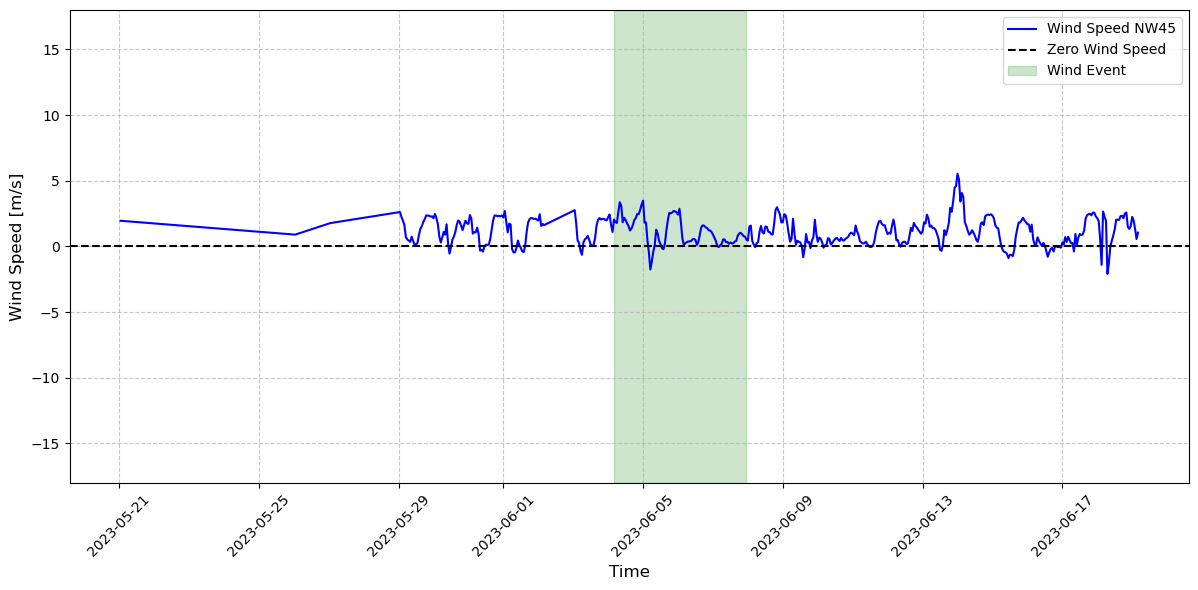

In [3]:
# Visualization NW45

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta


df = pd.read_csv('Data_HRDPS_PamRock.csv')

# 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 计算沿海峡方向风速 (Positive direction: NW 40)
wind_speed_NW40 = -df['U_component'] * np.cos(np.radians(45)) + df['V_component'] * np.cos(np.radians(45))


event_start = pd.to_datetime('2023-06-04 04:00:00') 
event_end = pd.to_datetime('2023-06-07 23:00:00')



# 确定绘图的时间窗口：这里我们直接用事件的开始时间作为中心，前后各看 15 天
max_wind_time = event_start 
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_NW40_month = wind_speed_NW40.loc[mask]
df_month = df.loc[mask]

# Visualization
plt.figure(figsize=(12, 6))

# 1. 画出风速折线和 0 基准线
plt.plot(df_month['valid_time'], wind_speed_NW40_month, label='Wind Speed NW45', color='b')
plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')


# background colour
plt.axvspan(event_start, event_end, color='green', alpha=0.2, label='Wind Event')

# 3. 图表美化与设置
plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) 

# 将图例放在外面或者最优位置，避免挡住高亮区域
plt.legend(loc='upper right') 
plt.tight_layout() 
plt.ylim([-18, 18])

# 显示图像
plt.show()

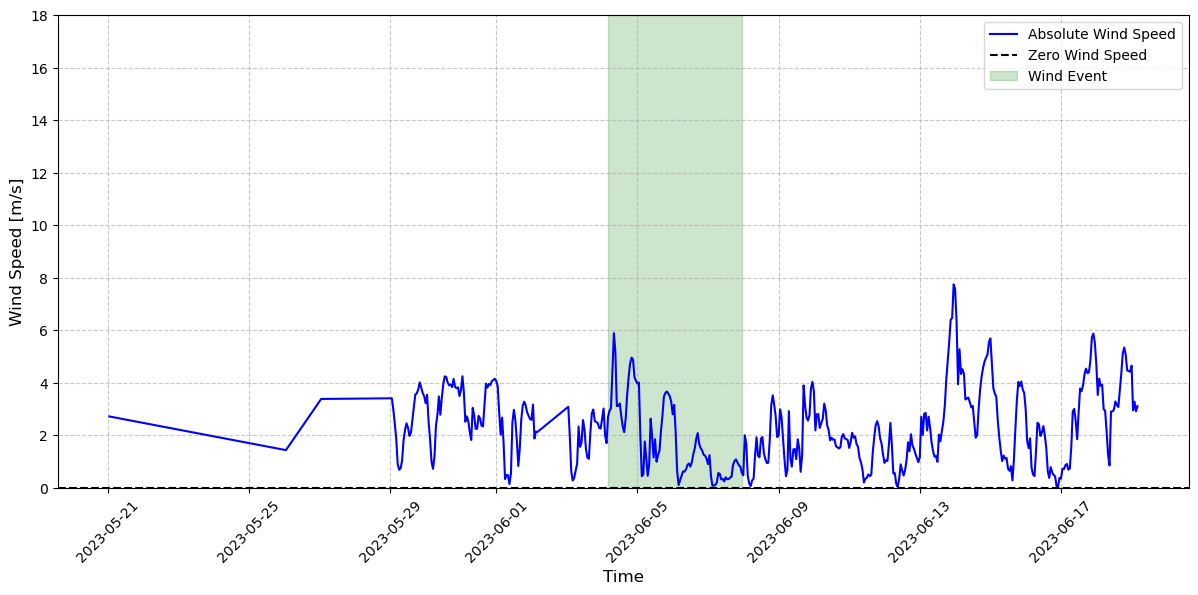

In [6]:
# Visualization Absolute

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta


df = pd.read_csv('Data_HRDPS_PamRock.csv')

# 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 计算沿海峡方向风速 (Positive direction: NW 40)
wind_speed = np.sqrt(df['U_component']**2 + df['V_component']**2)


event_start = pd.to_datetime('2023-06-04 04:00:00') 
event_end = pd.to_datetime('2023-06-07 23:00:00')



# 确定绘图的时间窗口：这里我们直接用事件的开始时间作为中心，前后各看 15 天
max_wind_time = event_start 
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_month = wind_speed.loc[mask]
df_month = df.loc[mask]

# Visualization
plt.figure(figsize=(12, 6))

# 1. 画出风速折线和 0 基准线
plt.plot(df_month['valid_time'], wind_speed_month, label='Absolute Wind Speed', color='b')
plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')


# background colour
plt.axvspan(event_start, event_end, color='green', alpha=0.2, label='Wind Event')

# 3. 图表美化与设置
plt.xlabel('Time', fontsize=12)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) 

# 将图例放在外面或者最优位置，避免挡住高亮区域
plt.legend(loc='upper right') 
plt.tight_layout() 
plt.ylim([0, 18])

# 显示图像
plt.show()

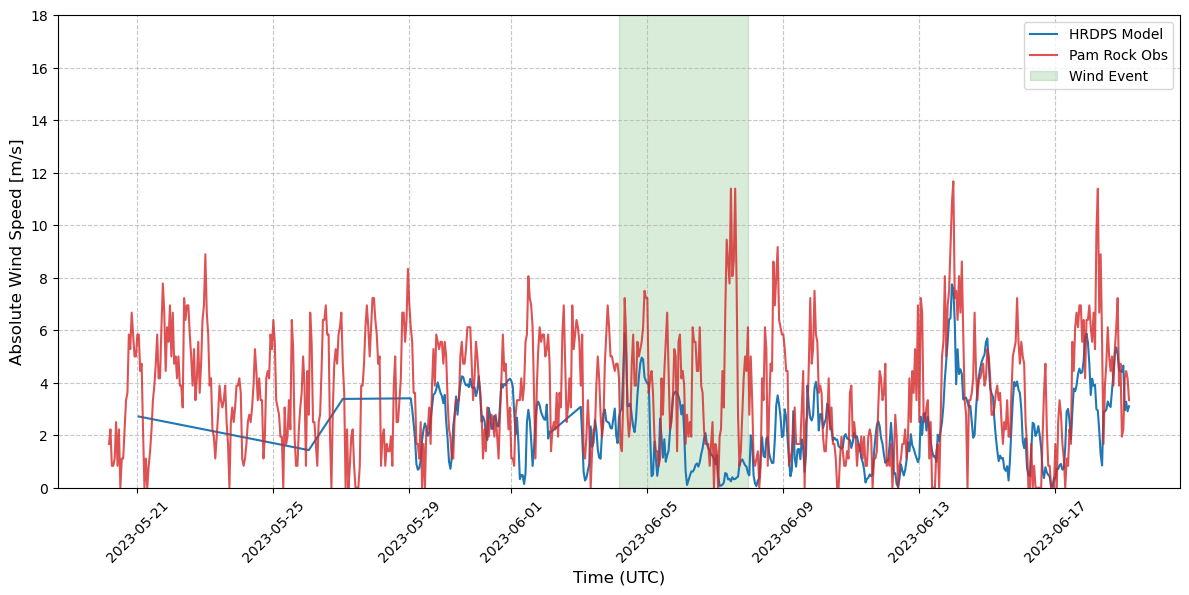

In [9]:
# HRDPS + Observation Absolute Wind Speed

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# ==========================================
# 1. 读取并处理 HRDPS 模型数据 (PamRock)
# ==========================================
df = pd.read_csv('Data_HRDPS_PamRock.csv')

# 将 'valid_time' 列转换为 datetime 格式，并按时间排序
df['valid_time'] = pd.to_datetime(df['valid_time'])
df = df.sort_values(by='valid_time', ascending=True).reset_index(drop=True)

# 计算绝对风速 (修正了原代码中 U 分量前的负号问题)
wind_speed = np.sqrt(df['U_component']**2 + df['V_component']**2)

# 定义事件和时间窗口
event_start = pd.to_datetime('2023-06-04 04:00:00') 
event_end = pd.to_datetime('2023-06-07 23:00:00')

# 确定绘图的时间窗口：这里我们直接用事件的开始时间作为中心，前后各看 15 天
max_wind_time = event_start 
start_time = max_wind_time - timedelta(days=15)
end_time = max_wind_time + timedelta(days=15)

# 根据时间窗口筛选模型数据
mask = (df['valid_time'] >= start_time) & (df['valid_time'] <= end_time)
wind_speed_month = wind_speed.loc[mask]
df_month = df.loc[mask]

# ==========================================
# 2. 动态读取并处理观测数据 (Pam Rock)
# ==========================================
obs_dir = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_vs_observation/Data_Pam_Rock_2008_2014'

# 找到时间窗口涉及的所有月份
months_to_load = pd.date_range(start=start_time.replace(day=1), end=end_time, freq='MS')
obs_df_list = []

for dt in months_to_load:
    # 构造文件名，例如: en_climate_hourly_BC_10459NN_06-2023_P1H.csv
    file_name = f"en_climate_hourly_BC_10459NN_{dt.strftime('%m-%Y')}_P1H.csv"
    file_path = os.path.join(obs_dir, file_name)
    
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path, low_memory=False)
        obs_df_list.append(temp_df)
    else:
        print(f"Warning: 找不到观测文件 {file_path}")

# 如果成功读取了观测数据，则进行拼接和计算
if obs_df_list:
    obs_df = pd.concat(obs_df_list, ignore_index=True)
    
    # 转换时间并筛选时间窗口
    obs_df['valid_time'] = pd.to_datetime(obs_df['Date/Time (UTC)'])
    obs_mask = (obs_df['valid_time'] >= start_time) & (obs_df['valid_time'] <= end_time)
    obs_df = obs_df.loc[obs_mask].copy()
    
    # 清洗数据：将风速转为数值类型，并进行单位转换
    # 观测数据直接提供了全风速：Wind Spd (km/h) -> 转换为 m/s 需要除以 3.6
    obs_df['obs_wind_speed'] = pd.to_numeric(obs_df['Wind Spd (km/h)'], errors='coerce') / 3.6

# ==========================================
# 3. Visualization 画图
# ==========================================
plt.figure(figsize=(12, 6))

# 画出模型绝对风速折线
plt.plot(df_month['valid_time'], wind_speed_month, label='HRDPS Model', color='#1f77b4', linewidth=1.5)

# 画出观测绝对风速折线 (如果有数据)
if obs_df_list and not obs_df.empty:
    plt.plot(obs_df['valid_time'], obs_df['obs_wind_speed'], label='Pam Rock Obs', color='#d62728', linewidth=1.5, alpha=0.8)

# 0 基准线
# plt.axhline(y=0, color='k', linestyle='--', label='Zero Wind Speed')

# 高亮背景区间
plt.axvspan(event_start, event_end, color='green', alpha=0.15, label='Wind Event')

# 图表美化与设置
# plt.title('Absolute Wind Speed - HRDPS vs Pam Rock Observation', fontsize=14, pad=15)
plt.xlabel('Time (UTC)', fontsize=12)
plt.ylabel('Absolute Wind Speed [m/s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) 

# 将图例放在外面或者最优位置
plt.legend(loc='upper right') 
plt.tight_layout() 
plt.ylim([0, 18])  # 因为是绝对值风速，Y轴下限保持为 0

# 显示图像
plt.show()

## Biological and chemical response

Reusing codes from `Analysis_Storm_Bio_Response`.

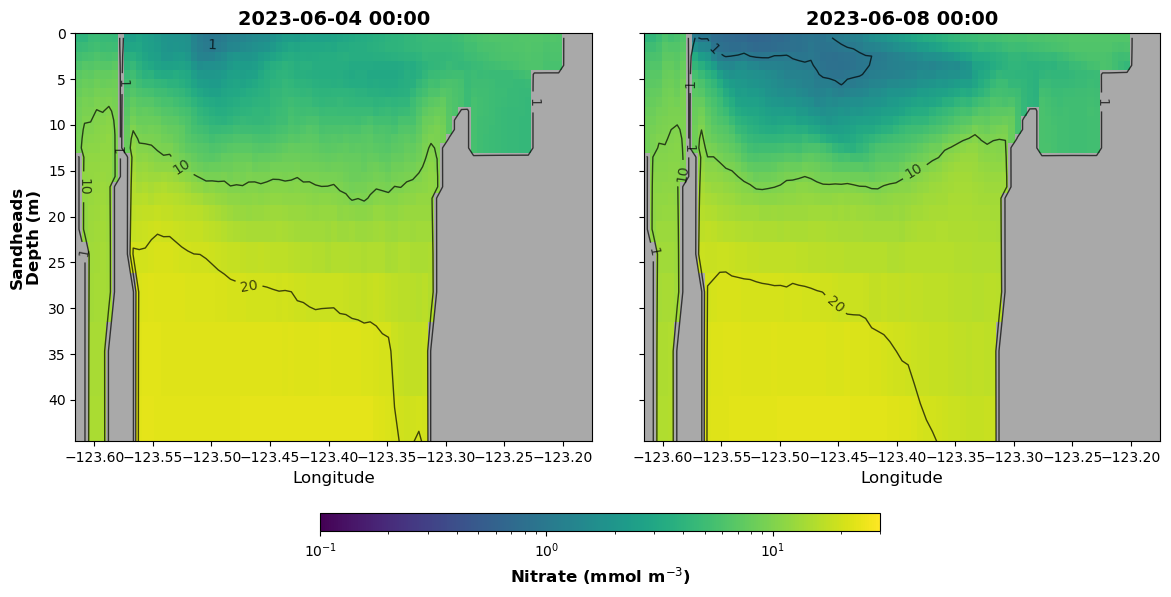

In [2]:
# 2023-06-04 vs 2023-06-08 nitrate section plot for Sandheads

import netCDF4 as nc
import numpy as np
import datetime
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

# dir
BASE_DIR = '/results2/SalishSea/nowcast-green.201905/'
FNAME_HEAD = 'SalishSea_1d_' 
FNAME_TAIL = '_ptrc_T.nc'

# section
SECTIONS = ['Sandheads']
TARGETS_DEFINITIONS = {
    'Sandheads': {'value': (49.11, -123.3), 'label': 'Sandheads'}
}

# 断面左右延伸的网格点数（你可以根据实际想要查看的范围微调）
SECTION_CONFIG = {
    'Sandheads': {'left_offset': 60, 'right_offset': 25},
}

DEPTH_LIMIT = 50

# 1x2 comparison
COLUMNS_INFO = [
    {'date': datetime.date(2023, 6, 4), 'title': '2023-06-04 00:00'},
    {'date': datetime.date(2023, 6, 8), 'title': '2023-06-08 00:00'},
]

# functions
def find_nearest_indices_2d(lon_2d, lat_2d, target_lon, target_lat):
    dist_sq = (lon_2d - target_lon)**2 + (lat_2d - target_lat)**2
    return np.unravel_index(dist_sq.argmin(), lon_2d.shape)

def load_nitrate_data(date_obj, y_idx, x_idx, config, lon_2d):
    file_path = os.path.join(
        BASE_DIR,
        date_obj.strftime('%d%b%y').lower(),
        f"{FNAME_HEAD}{date_obj.strftime('%Y%m%d')}_{date_obj.strftime('%Y%m%d')}{FNAME_TAIL}"
    )
    
    if not os.path.exists(file_path): 
        print(f"Warning: File not found -> {file_path}")
        return None
    
    with nc.Dataset(file_path, 'r') as ncfile:
        z_var = ncfile.variables['deptht'][:]
        z_idx_limit = np.abs(z_var - DEPTH_LIMIT).argmin()
        
        x_start = max(0, x_idx - config['left_offset'])
        x_end = min(lon_2d.shape[1], x_idx + config['right_offset'])
        x_slice = slice(x_start, x_end)
        
        nitrate = ncfile.variables['nitrate'][0, :z_idx_limit+1, y_idx, x_slice]
        lon_sec = lon_2d[y_idx, x_slice]
        
        return nitrate, lon_sec, z_var[:z_idx_limit+1]

def plot_single_panel(ax, data, lon, depths):
    ax.set_facecolor('darkgray') 
    
    # nitrate
    cmap = 'viridis'
    vmin, vmax = 0.1, 30
    contour_levels = [1, 10, 20]

    data_masked = np.ma.masked_less_equal(data, 0)
    X, Z = np.meshgrid(lon, depths)
    
    cf = ax.pcolormesh(X, Z, data_masked, 
                       norm=LogNorm(vmin=vmin, vmax=vmax),
                       cmap=cmap, shading='auto')
    
    cs = ax.contour(X, Z, data, levels=contour_levels,
                    colors='black', linewidths=1, alpha=0.7)
    
    ax.clabel(cs, fontsize=10)
    
    ax.set_ylim(depths.max(), 0)
    
    return cf

# main
def main():
    # 动态获取第一天的数据文件作为经纬度模板
    sample_date = COLUMNS_INFO[0]['date']
    sample_coord_file = os.path.join(
        BASE_DIR,
        sample_date.strftime('%d%b%y').lower(),
        f"{FNAME_HEAD}{sample_date.strftime('%Y%m%d')}_{sample_date.strftime('%Y%m%d')}{FNAME_TAIL}"
    )
    
    if not os.path.exists(sample_coord_file):
        print(f"Error: 无法找到坐标模板文件 {sample_coord_file}")
        return

    with nc.Dataset(sample_coord_file, 'r') as nf:
        lon_2d = nf.variables['nav_lon'][:]
        lat_2d = nf.variables['nav_lat'][:]

    # 改为 1x2 的图幅布局
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    plt.subplots_adjust(wspace=0.1, bottom=0.2)

    cf_ref = None
    p_id = SECTIONS[0]
    p_def = TARGETS_DEFINITIONS[p_id]

    # 获取 Sandheads 对应的网格索引
    y_idx, x_idx = find_nearest_indices_2d(
        lon_2d, lat_2d,
        p_def['value'][1], p_def['value'][0]
    )

    for col_idx, col_info in enumerate(COLUMNS_INFO):
        ax = axes[col_idx]

        res = load_nitrate_data(
            col_info['date'],
            y_idx, x_idx,
            SECTION_CONFIG[p_id],
            lon_2d
        )

        if res is None:
            ax.text(0.5, 0.5, 'Data Missing', ha='center', va='center')
            ax.set_title(col_info['title'], fontsize=14, fontweight='bold')
            continue

        nitrate, lon_s, depth_s = res
        cf = plot_single_panel(ax, nitrate, lon_s, depth_s)
        cf_ref = cf

        # 标题和坐标轴标签
        ax.set_title(col_info['title'], fontsize=14, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12)

        if col_idx == 0:
            ax.set_ylabel(f"{p_def['label']}\nDepth (m)", fontsize=12, fontweight='bold')

    # unified colorbar
    if cf_ref:
        cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.03])
        cbar = fig.colorbar(cf_ref, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('Nitrate (mmol m$^{-3}$)', fontsize=12, fontweight='bold')

    plt.show()

if __name__ == '__main__':
    main()

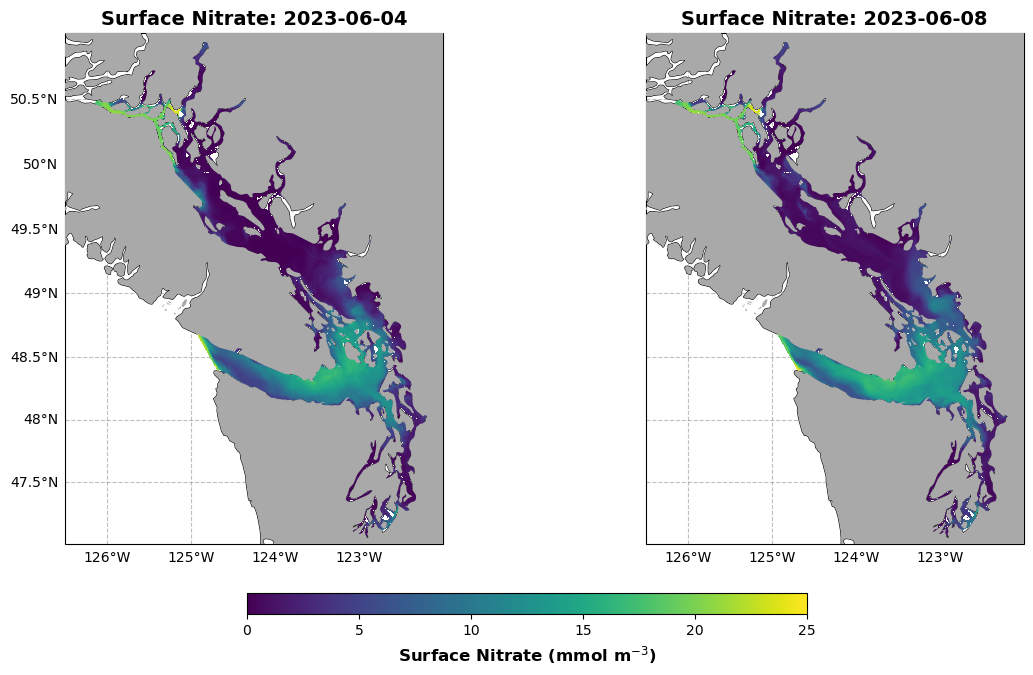

In [ ]:
import netCDF4 as nc
import numpy as np
import datetime
import os
import matplotlib.pyplot as plt

# 引入 cartopy 相关模块
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 目录配置
BASE_DIR = '/results2/SalishSea/nowcast-green.201905/'
FNAME_HEAD = 'SalishSea_1d_' 
FNAME_TAIL = '_ptrc_T.nc'

# 需要对比的日期
DATES_TO_PLOT = [
    {'date': datetime.date(2023, 6, 4), 'title': 'Surface Nitrate: 2023-06-04'},
    {'date': datetime.date(2023, 6, 8), 'title': 'Surface Nitrate: 2023-06-08'},
]



def load_surface_nitrate(date_obj):

    """读取指定日期的表层 (depth index = 0) 硝酸盐数据"""
    file_path = os.path.join(
        BASE_DIR,
        date_obj.strftime('%d%b%y').lower(),
        f"{FNAME_HEAD}{date_obj.strftime('%Y%m%d')}_{date_obj.strftime('%Y%m%d')}{FNAME_TAIL}"
    )
    
    if not os.path.exists(file_path): 
        print(f"Warning: File not found -> {file_path}")
        return None, None, None
    
    with nc.Dataset(file_path, 'r') as ncfile:
        # 提取数据，并强制转换为普通的 float 数组，解除 netCDF 的只读限制
        lon = ncfile.variables['nav_lon'][:].astype(float)
        lat = ncfile.variables['nav_lat'][:].astype(float)
        surface_nitrate = ncfile.variables['nitrate'][0, 0, :, :].astype(float)
        
        # 简单粗暴：直接将 0 替换为 np.nan
        lon[lon == 0] = np.nan
        lat[lat == 0] = np.nan
        surface_nitrate[surface_nitrate == 0] = np.nan
        
        return surface_nitrate, lon, lat

def main():
    # 使用墨卡托投影作为地图框架
    proj = ccrs.Mercator()
    # 数据本身的坐标系是普通的经纬度
    data_crs = ccrs.PlateCarree()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': proj})
    plt.subplots_adjust(wspace=0.15, bottom=0.15)
    
    cf_ref = None

    for col_idx, date_info in enumerate(DATES_TO_PLOT):
        ax = axes[col_idx]
        
        nitrate_data, lon, lat = load_surface_nitrate(date_info['date'])
        

        if nitrate_data is None:
            ax.text(0.5, 0.5, 'Data Missing', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(date_info['title'], fontsize=14, fontweight='bold')
            continue
            
        # 根据模型网格
        ax.set_extent([-126.5, -122, 47, 51], crs=data_crs)
        
        # 添加 Cartopy 自带的地理特征 (陆地、海岸线)
        
        ax.add_feature(cfeature.LAND, facecolor='darkgray', zorder=5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=2)
        

        
        # 绘制平面图 (必须加上 transform=data_crs，告诉 Cartopy 你的数据是经纬度)
        cf = ax.pcolormesh(lon, lat, nitrate_data, 
                           transform=data_crs,
                           cmap='viridis', vmin=0, vmax=25, shading='auto', zorder=3)
        cf_ref = cf
        

        
        # 添加带刻度的经纬度网格线
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
        gl.top_labels = False   # 隐藏顶部的刻度
        gl.right_labels = False # 隐藏右侧的刻度
        if col_idx != 0:
            gl.left_labels = False # 第二张图隐藏左侧 Y 轴刻度，实现 sharey 效果
            
        ax.set_title(date_info['title'], fontsize=14, fontweight='bold')


    # 添加统一的 Colorbar
    if cf_ref:
        cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.03])
        cbar = fig.colorbar(cf_ref, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('Surface Nitrate (mmol m$^{-3}$)', fontsize=12, fontweight='bold')

    plt.show()

if __name__ == '__main__':
    main()